# 04 Event-Window Descriptive Diagnostics

This notebook runs exploratory monthly event-window diagnostics on the merged salience-polling panel.

Scope:
- Descriptive only.
- No causal claims.
- No event-study regression or significance testing as the main goal.
- Objective is to inspect pre/post patterns around key shock months.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

PANEL_DIR = PROJECT_ROOT / 'data' / 'panel'
FIGURES_DIR = PROJECT_ROOT / 'figures' / '04_notebook_figures'
OUTPUT_TABLE_DIR = PANEL_DIR

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)

PANEL_PARQUET_PATH = PANEL_DIR / 'monthly_salience_polling_panel.parquet'
PANEL_CSV_PATH = PANEL_DIR / 'monthly_salience_polling_panel.csv'
EVENT_SUMMARY_CSV_PATH = OUTPUT_TABLE_DIR / 'event_window_descriptive_summary.csv'

ANALYSIS_START = pd.Timestamp('2017-01-01')
ANALYSIS_END = pd.Timestamp('2025-12-31')
EXPECTED_ROWS = 108

print('PROJECT_ROOT:', PROJECT_ROOT)
print('PANEL_PARQUET_PATH:', PANEL_PARQUET_PATH)
print('EVENT_SUMMARY_CSV_PATH:', EVENT_SUMMARY_CSV_PATH)
print('FIGURES_DIR:', FIGURES_DIR)

PROJECT_ROOT: c:\PythonProjects\AfD-project
PANEL_PARQUET_PATH: c:\PythonProjects\AfD-project\data\panel\monthly_salience_polling_panel.parquet
EVENT_SUMMARY_CSV_PATH: c:\PythonProjects\AfD-project\data\panel\event_window_descriptive_summary.csv
FIGURES_DIR: c:\PythonProjects\AfD-project\figures\04_notebook_figures


In [2]:
def load_panel() -> pd.DataFrame:
    if PANEL_PARQUET_PATH.exists():
        return pd.read_parquet(PANEL_PARQUET_PATH)
    if PANEL_CSV_PATH.exists():
        return pd.read_csv(PANEL_CSV_PATH)
    raise FileNotFoundError(f'Missing panel files: {PANEL_PARQUET_PATH} and {PANEL_CSV_PATH}')

panel = load_panel().copy()
panel['month_dt'] = pd.to_datetime(panel['month_dt'], errors='coerce')
panel['year_month'] = panel['month_dt'].dt.strftime('%Y-%m')

required_cols = [
    'year_month', 'month_dt', 'afd_poll_support_mean', 'afd_poll_support_z',
    'nexis_total_results', 'media_salience_volume_z', 'n_polls'
]
missing_cols = [c for c in required_cols if c not in panel.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

if panel['year_month'].duplicated().any():
    dupes = panel.loc[panel['year_month'].duplicated(), 'year_month'].tolist()
    raise ValueError(f'Duplicate year_month rows: {dupes[:10]}')

if panel['month_dt'].isna().any():
    raise ValueError('month_dt contains unparseable values')

panel = panel.sort_values('month_dt').reset_index(drop=True)

if panel['month_dt'].min().to_period('M') != ANALYSIS_START.to_period('M') or panel['month_dt'].max().to_period('M') != ANALYSIS_END.to_period('M'):
    raise ValueError(
        f'Unexpected panel month coverage: {panel["month_dt"].min()} to {panel["month_dt"].max()} '
        f'(expected months {ANALYSIS_START.to_period("M")} to {ANALYSIS_END.to_period("M")})'
    )

if len(panel) != EXPECTED_ROWS:
    raise ValueError(f'Unexpected panel row count: {len(panel)} (expected {EXPECTED_ROWS})')

print('panel shape:', panel.shape)
print('coverage:', panel['month_dt'].min(), 'to', panel['month_dt'].max())
print('required columns validated')
print(panel[required_cols].head())
print('Basic summary:')
print(panel[['afd_poll_support_mean', 'nexis_total_results', 'media_salience_volume_z', 'n_polls']].describe())

panel shape: (108, 34)
coverage: 2017-01-01 00:00:00 to 2025-12-01 00:00:00
required columns validated
  year_month   month_dt  afd_poll_support_mean  afd_poll_support_z  nexis_total_results  media_salience_volume_z  n_polls
0    2017-01 2017-01-01              12.186667           -0.521216                  255                 0.494077       15
1    2017-02 2017-02-01              10.356522           -0.909724                  239                 0.388611       23
2    2017-03 2017-03-01               9.529167           -1.085357                  239                 0.388611       24
3    2017-04 2017-04-01               9.064286           -1.184043                  179                -0.006887       28
4    2017-05 2017-05-01               8.258621           -1.355072                  171                -0.059620       29
Basic summary:
       afd_poll_support_mean  nexis_total_results  media_salience_volume_z     n_polls
count             108.000000           108.000000              

In [3]:
shock_meta = pd.DataFrame([
    {
        'shock_label': 'Chemnitz',
        'shock_month': pd.Timestamp('2018-08-01'),
        'expected_direction': 'ambiguous',
        'mechanism': 'law_order_far_right_mobilization',
    },
    {
        'shock_label': 'Correctiv',
        'shock_month': pd.Timestamp('2024-01-01'),
        'expected_direction': 'decrease',
        'mechanism': 'democratic_threat_remigration',
    },
])

print(shock_meta)
print('Note: Cologne 2016 is outside current DAWUM panel and is not included in event-window calculations.')

  shock_label shock_month expected_direction                         mechanism
0    Chemnitz  2018-08-01          ambiguous  law_order_far_right_mobilization
1   Correctiv  2024-01-01           decrease     democratic_threat_remigration
Note: Cologne 2016 is outside current DAWUM panel and is not included in event-window calculations.


In [4]:
def extract_event_window(df: pd.DataFrame, shock_month: pd.Timestamp, pre_months: int = 6, post_months: int = 6) -> pd.DataFrame:
    start = shock_month - pd.DateOffset(months=pre_months)
    end = shock_month + pd.DateOffset(months=post_months)

    w = df[(df['month_dt'] >= start) & (df['month_dt'] <= end)].copy()
    w['rel_month'] = ((w['month_dt'].dt.year - shock_month.year) * 12 + (w['month_dt'].dt.month - shock_month.month)).astype(int)
    w = w.sort_values('month_dt').reset_index(drop=True)
    return w


def compute_pre_post_summary(w: pd.DataFrame, shock_label: str, shock_month: pd.Timestamp, pre_months: int, post_months: int) -> dict:
    pre = w[w['rel_month'] < 0]
    post = w[w['rel_month'] > 0]
    shock_row = w[w['rel_month'] == 0]

    afd_shock = float(shock_row['afd_poll_support_mean'].iloc[0]) if len(shock_row) == 1 else np.nan
    salience_shock = float(shock_row['media_salience_volume_z'].iloc[0]) if len(shock_row) == 1 else np.nan

    out = {
        'shock_label': shock_label,
        'shock_month': shock_month.strftime('%Y-%m'),
        'pre_months': pre_months,
        'post_months': post_months,
        'afd_pre_mean': pre['afd_poll_support_mean'].mean(),
        'afd_post_mean': post['afd_poll_support_mean'].mean(),
        'afd_change_post_minus_pre': post['afd_poll_support_mean'].mean() - pre['afd_poll_support_mean'].mean(),
        'salience_pre_mean': pre['media_salience_volume_z'].mean(),
        'salience_post_mean': post['media_salience_volume_z'].mean(),
        'salience_change_post_minus_pre': post['media_salience_volume_z'].mean() - pre['media_salience_volume_z'].mean(),
        'afd_shock_month': afd_shock,
        'salience_shock_month': salience_shock,
        'n_months_pre': int(len(pre)),
        'n_months_post': int(len(post)),
    }
    return out

In [5]:
summaries = []
for _, shock in shock_meta.iterrows():
    for win in [3, 6]:
        w = extract_event_window(panel, shock['shock_month'], pre_months=win, post_months=win)
        summaries.append(compute_pre_post_summary(w, shock['shock_label'], shock['shock_month'], win, win))

event_summary = pd.DataFrame(summaries)
event_summary = event_summary.sort_values(['shock_month', 'pre_months']).reset_index(drop=True)

print('Event-window descriptive summary:')
print(event_summary)

event_summary.to_csv(EVENT_SUMMARY_CSV_PATH, index=False)
print('Saved:', EVENT_SUMMARY_CSV_PATH)

Event-window descriptive summary:
  shock_label shock_month  pre_months  post_months  afd_pre_mean  afd_post_mean  afd_change_post_minus_pre  salience_pre_mean  salience_post_mean  salience_change_post_minus_pre  \
0    Chemnitz     2018-08           3            3     15.070079      15.515632                   0.445552           0.421569            0.199650                       -0.221918   
1    Chemnitz     2018-08           6            6     14.462367      14.529741                   0.067374           0.109565            0.135931                        0.026367   
2   Correctiv     2024-01           3            3     21.508152      18.228030                  -3.280122           0.322694           -0.488077                       -0.810771   
3   Correctiv     2024-01           6            6     21.172471      17.519438                  -3.653033           0.039254           -0.483682                       -0.522936   

   afd_shock_month  salience_shock_month  n_months_pre  n_mo

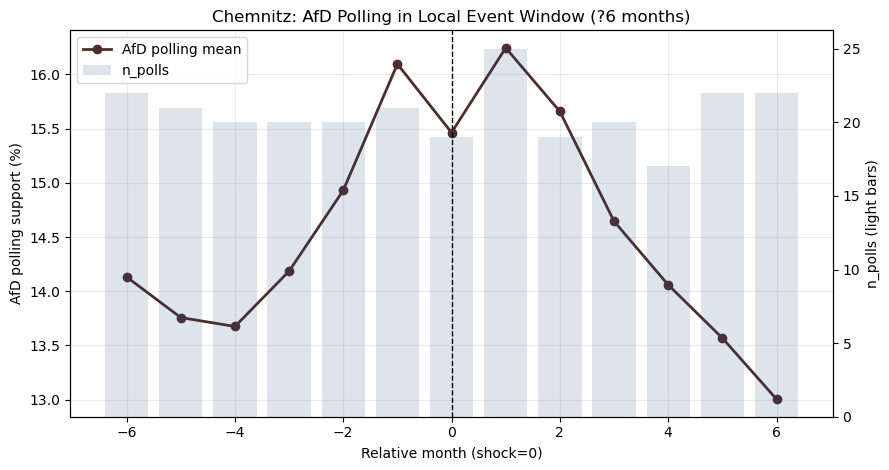

Saved: c:\PythonProjects\AfD-project\figures\04_notebook_figures\chemnitz_afd_polling_event_window.png


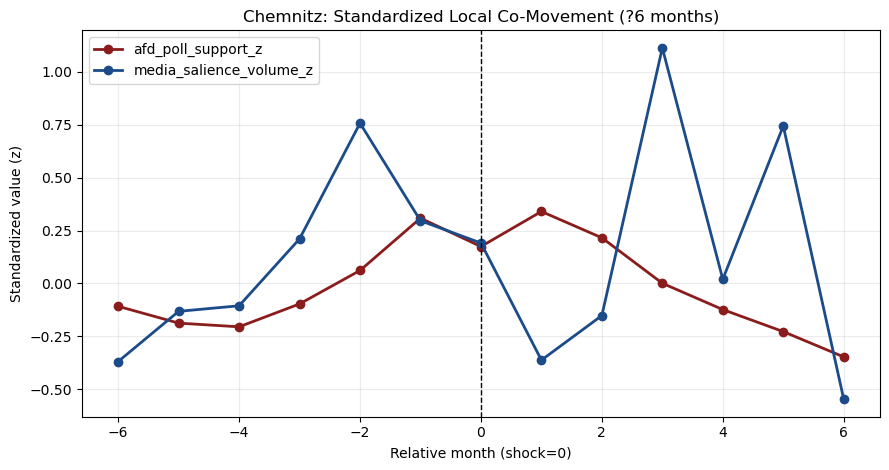

Saved: c:\PythonProjects\AfD-project\figures\04_notebook_figures\chemnitz_comovement_event_window.png


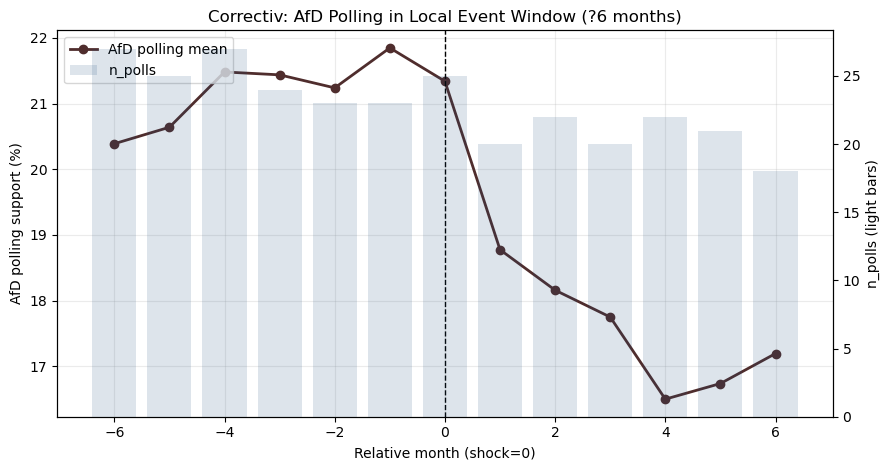

Saved: c:\PythonProjects\AfD-project\figures\04_notebook_figures\correctiv_afd_polling_event_window.png


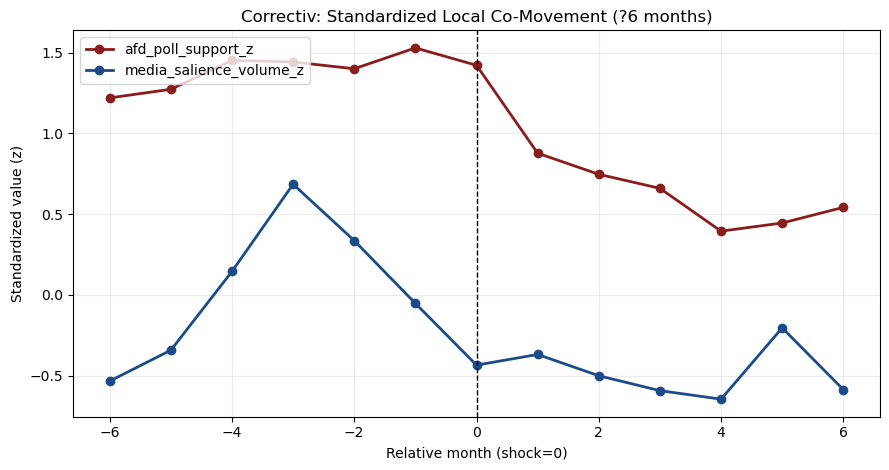

Saved: c:\PythonProjects\AfD-project\figures\04_notebook_figures\correctiv_comovement_event_window.png


In [6]:
def plot_local_windows(panel_df: pd.DataFrame, shock_label: str, shock_month: pd.Timestamp, window_months: int = 6):
    w = extract_event_window(panel_df, shock_month, pre_months=window_months, post_months=window_months)

    # A) AfD polling around shock
    fig, ax1 = plt.subplots(figsize=(9, 4.8))
    ax1.plot(w['rel_month'], w['afd_poll_support_mean'], marker='o', color='#4f2d2d', linewidth=2, label='AfD polling mean')
    ax1.axvline(0, color='black', linestyle='--', linewidth=1)
    ax1.set_xlabel('Relative month (shock=0)')
    ax1.set_ylabel('AfD polling support (%)')
    ax1.set_title(f'{shock_label}: AfD Polling in Local Event Window (?{window_months} months)')
    ax1.grid(alpha=0.25)

    # light n_polls annotation via secondary axis bar
    ax2 = ax1.twinx()
    ax2.bar(w['rel_month'], w['n_polls'], alpha=0.15, color='#1f4e79', width=0.8, label='n_polls')
    ax2.set_ylabel('n_polls (light bars)')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    fig.tight_layout()

    name_base = shock_label.lower()
    out_poll = FIGURES_DIR / f'{name_base}_afd_polling_event_window.png'
    fig.savefig(out_poll, dpi=150)
    plt.show()
    print('Saved:', out_poll)

    # B) Standardized local co-movement
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.plot(w['rel_month'], w['afd_poll_support_z'], marker='o', color='#8a1c1c', linewidth=2, label='afd_poll_support_z')
    ax.plot(w['rel_month'], w['media_salience_volume_z'], marker='o', color='#1c4b8a', linewidth=2, label='media_salience_volume_z')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Relative month (shock=0)')
    ax.set_ylabel('Standardized value (z)')
    ax.set_title(f'{shock_label}: Standardized Local Co-Movement (?{window_months} months)')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper left')

    fig.tight_layout()
    out_co = FIGURES_DIR / f'{name_base}_comovement_event_window.png'
    fig.savefig(out_co, dpi=150)
    plt.show()
    print('Saved:', out_co)

for _, shock in shock_meta.iterrows():
    plot_local_windows(panel, shock['shock_label'], shock['shock_month'], window_months=6)

In [7]:
panel_fd = panel.copy()
panel_fd['afd_poll_support_change'] = panel_fd['afd_poll_support_mean'].diff()
panel_fd['media_salience_volume_change'] = panel_fd['nexis_total_results'].diff()

fd_cols = [
    'rel_month', 'year_month', 'afd_poll_support_mean', 'afd_poll_support_change',
    'nexis_total_results', 'media_salience_volume_change', 'media_salience_volume_z', 'n_polls'
]

for _, shock in shock_meta.iterrows():
    w = extract_event_window(panel_fd, shock['shock_month'], pre_months=6, post_months=6)
    print(f"First-difference diagnostic | {shock['shock_label']} (?6 months)")
    print(w[fd_cols].to_string(index=False))
    print()

First-difference diagnostic | Chemnitz (?6 months)
 rel_month year_month  afd_poll_support_mean  afd_poll_support_change  nexis_total_results  media_salience_volume_change  media_salience_volume_z  n_polls
        -6    2018-02              14.131818                 1.381818                  124                        -102.0                -0.369427       22
        -5    2018-03              13.757143                -0.374675                  160                          36.0                -0.132128       21
        -4    2018-04              13.675000                -0.082143                  164                           4.0                -0.105762       20
        -3    2018-05              14.185000                 0.510000                  212                          48.0                 0.210636       20
        -2    2018-06              14.930000                 0.745000                  295                          83.0                 0.757742       20
        -1    2018-

## Interpretation Notes (Descriptive)

- Chemnitz is theoretically relevant but descriptively ambiguous in a volume-based salience framework.
- Correctiv is descriptively promising for a potential negative polling-shift pattern if AfD support declines after 2024-01.
- Broad migration/public-order salience may not fully capture mechanism-specific framing; later work may require content/framing indicators.
- Cologne is outside the current DAWUM panel and requires a historical polling supplement for quantitative inclusion.
- These diagnostics motivate next checks but do not establish causal effects.
